## Problem Statement
Task 1:-Prepare a complete data analysis report on the given data.

Task 2:- Build a model that can accurately predicts the performance of the students.

## Dataset Information
The data consist of evaluations of teaching performance over three regular semesters and two summer semesters of 151 teaching assistant (TA) assignments at the Statistics Department of the University of Wisconsin-Madison. The scores were divided into 3 roughly equal-sized categories ("low", "medium", and "high") to form the class variable.

## Attribute Information:
- Native_teacher: Whether or not the TA is a native English speaker (binary); 1=English speaker, 2=non-English speaker
- Instructor: Course instructor (categorical, 25 categories)
- Course (categorical, 26 categories)
- Semester: Whether instructor took classes in Summer(1) or Regular(2)
- Class size (numerical): How many participants joined the session.
- Class attribute (categorical) 1=Low, 2=Medium, 3=High

## Buisness case:
Create a report stating the performance of multiple models on this data and suggest the best model for production. Create a report which should include challenges you faced on data and what technique used with proper reason.

In [1]:
## Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
from pandas import Series, DataFrame
from scipy import stats
import klib

# To Avoid Warnings
import warnings
warnings.filterwarnings('ignore')

# to visualise all the columns in the dataframe
#pd.pandas.set_option('display.max_columns', None)

# importing metrics for model evaluation
from sklearn import metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, f1_score, recall_score, precision_score

In [2]:
df=pd.read_csv('tae.csv')
df

,1,23,3,1.1,19,3.1
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3
...,...,...,...,...,...,...
145,2,3,2,2,26,1
146,2,10,3,2,12,1
147,1,18,7,2,48,1
148,2,22,1,2,51,1


In [3]:
df= df.rename(columns={'1': 'speaker',"23":"Course_instructor","3":"Course","1.1":"semester","19":"Class_size",
                           "3.1":"Class_attribute"})
df

,speaker,Course_instructor,Course,semester,Class_size,Class_attribute
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3
...,...,...,...,...,...,...
145,2,3,2,2,26,1
146,2,10,3,2,12,1
147,1,18,7,2,48,1
148,2,22,1,2,51,1


In [4]:
df["Class_attribute"].unique()    # unique value in the tatrget variable

array([3, 2, 1], dtype=int64)

In [5]:
df.info()# To check  data type and  non null value of all columns  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   speaker            150 non-null    int64
 1   Course_instructor  150 non-null    int64
 2   Course             150 non-null    int64
 3   semester           150 non-null    int64
 4   Class_size         150 non-null    int64
 5   Class_attribute    150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


## Domain Analysis:
The given dataset contains evaluations of teaching performance for 151 teaching assistant (TA) assignments at the Statistics Department of the University of Wisconsin-Madison. The dataset includes various attributes that can provide insights into the factors affecting the performance of the TAs.

- Native_teacher: This attribute indicates whether the TA is a native English speaker or not. It is a binary variable with values 1 and 2, representing English speakers and non-English speakers, respectively. The language proficiency of TAs may play a role in their teaching effectiveness, as it can affect their communication with students.

- Instructor: This attribute represents the course instructor and is a categorical variable with 25 categories. Different instructors may have different teaching styles, approaches, and expertise, which can influence the overall teaching performance of TAs.

- Course: This attribute represents the course being taught and is a categorical variable with 26 categories. The nature of the course, its difficulty level, and the subject matter can impact the teaching experience and performance of TAs.

- Semester: This attribute indicates whether the TA taught classes during the summer or regular semesters. It is a binary variable with values 1 and 2, representing summer and regular semesters, respectively. The teaching environment and dynamics may vary between these two semesters, which could influence the TA's performance.

- Class size: This attribute represents the number of participants who joined the TA session. It is a numerical variable that can provide insights into the scale and complexity of the teaching environment. Larger class sizes may pose different challenges and require different teaching strategies compared to smaller class sizes.

- Class attribute: This attribute is the target variable and represents the evaluation scores divided into three categories: low, medium, and high. It is a categorical variable with values 1, 2, and 3, respectively. The class attribute indicates the overall performance of TAs based on the evaluations.

- By analyzing these attributes, we can explore the relationships between various factors and the teaching performance of TAs. This analysis can help identify patterns, trends, and potential predictors of performance, which can be utilized to build a predictive model accurately forecasting the performance of future TAs.

In [6]:
df.describe()#used to view some basic statistical details like percentile, mean, std etc. 

,speaker,Course_instructor,Course,semester,Class_size,Class_attribute
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.813333,13.580000,8.140000,1.853333,27.926667,2.013333
std,0.390949,6.805318,7.034937,0.354958,12.916405,0.819123
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.500000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


## Insights:

Speaker: The majority of the students in the dataset (mean = 1.81) are English speakers, with a minimum value of 1 and a maximum value of 2. This indicates that the dataset includes both English speakers and non-English speakers.

Course Instructor: The average course instructor number is around 13.58, with a minimum of 1 and a maximum of 25. This suggests that there are various instructors involved in teaching the courses.

Course: The dataset consists of various courses, with an average course number of 8.14. The courses range from a minimum of 1 to a maximum of 26.

Semester: The average semester number is approximately 1.85, indicating that the majority of the students in the dataset are in their first semester. The semester values range from 1 to 2.

Class Size: The average class size is around 27.93 students, with a minimum of 3 and a maximum of 66. The dataset contains classes of different sizes, with a relatively wide range.

Class Attribute: The class attribute values range from 1 to 3, indicating different class attributes or characteristics. The majority of the classes fall under attribute 2, as the mean is 2.01.

In [7]:
# To get number of rows and columns of the dataset

df.shape

(150, 6)

In [8]:
df["Class_attribute"].isnull().sum() ##checking null values

0

In [9]:
# To check all the null values from the dataset

df.isnull().sum()

speaker              0
Course_instructor    0
Course               0
semester             0
Class_size           0
Class_attribute      0
dtype: int64

In [10]:
# To check the type of features.

df.dtypes

speaker              int64
Course_instructor    int64
Course               int64
semester             int64
Class_size           int64
Class_attribute      int64
dtype: object

## Exploratory Data Analysis:

#### EDA Using klib library

<AxesSubplot:xlabel='Class_attribute', ylabel='Density'>

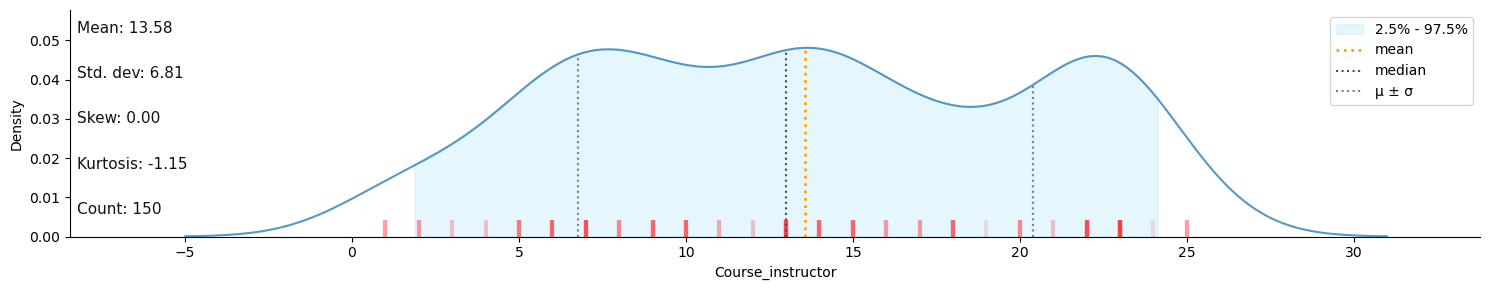

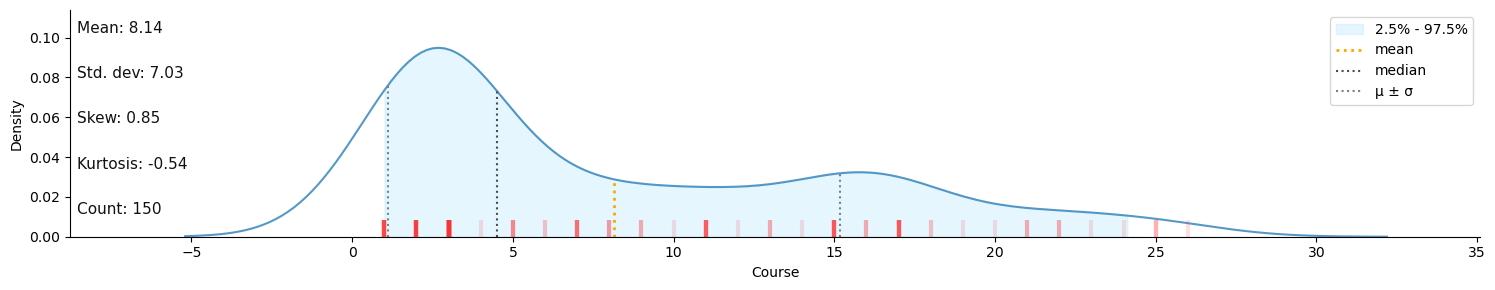

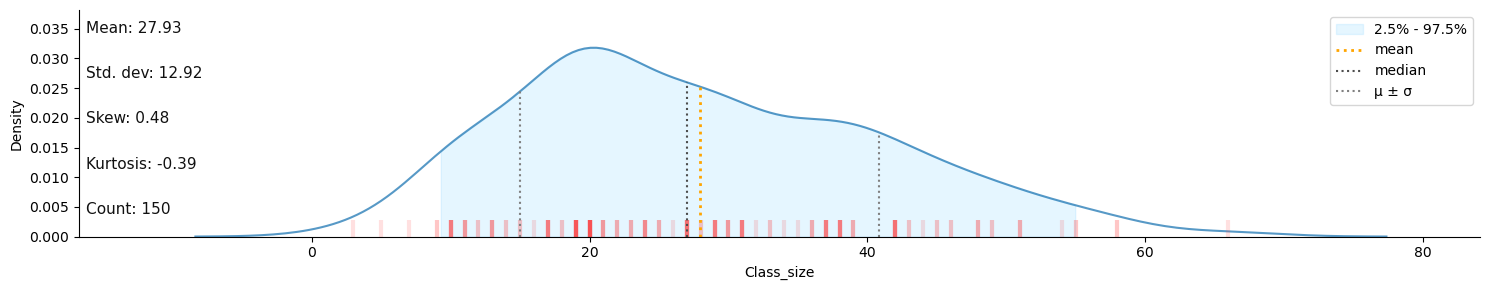

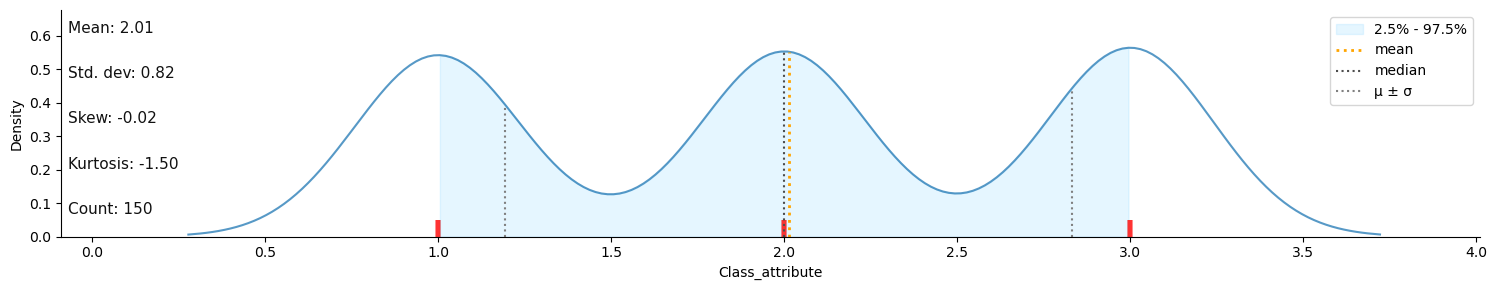

In [11]:
klib.dist_plot(df) # returns a distribution plot for every numeric feature

In [12]:
# klib.clean - functions for cleaning datasets
klib.data_cleaning(df) # performs datacleaning (drop duplicates & empty rows/cols, adjust dtypes,...)

Shape of cleaned data: (110, 6) - Remaining NAs: 0


Dropped rows: 40
     of which 40 duplicates. (Rows (first 150 shown): [39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 85, 137, 138])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.01 MB (-100.0%)



,speaker,course_instructor,course,semester,class_size,class_attribute
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3
...,...,...,...,...,...,...
105,2,3,2,2,26,1
106,2,10,3,2,12,1
107,1,18,7,2,48,1
108,2,22,1,2,51,1


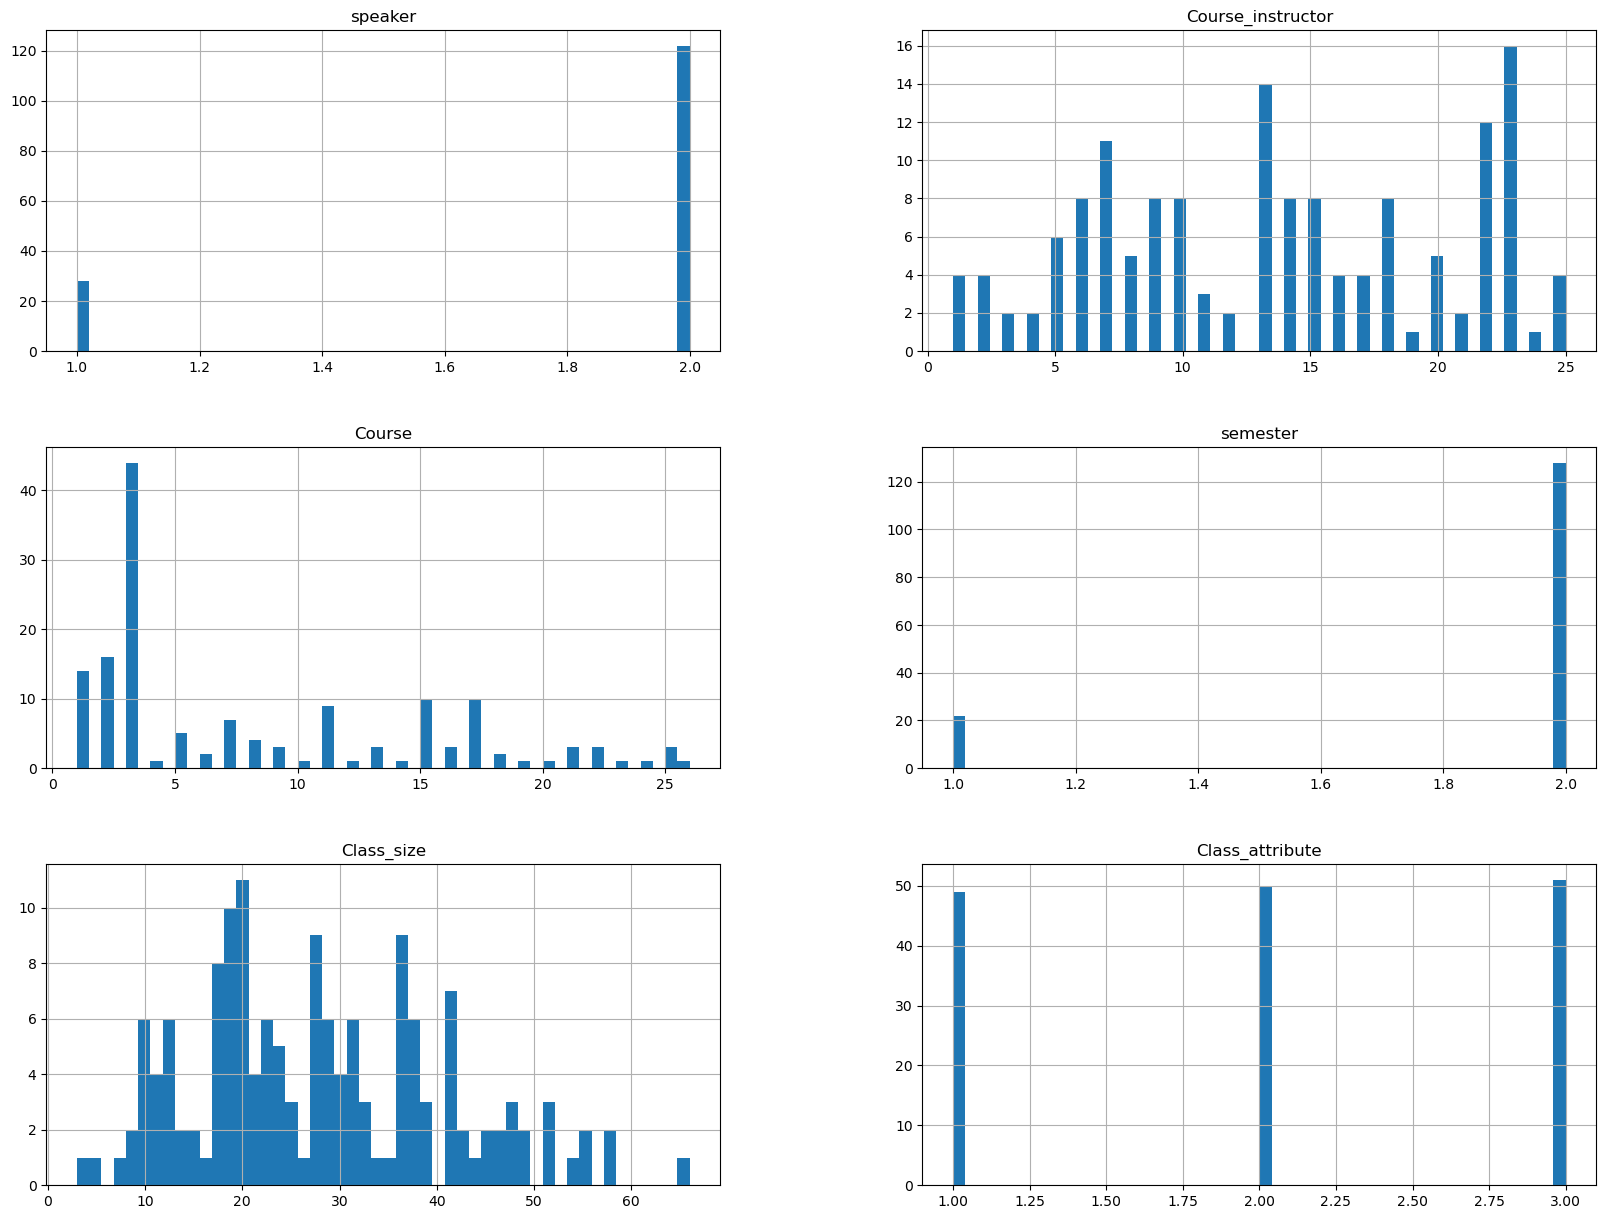

In [13]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [14]:
## assigning the dependent column in a seperate variable in below

In [15]:
df1=df[['speaker', 'Course_instructor', 'Course', 'semester','Class_size']]     

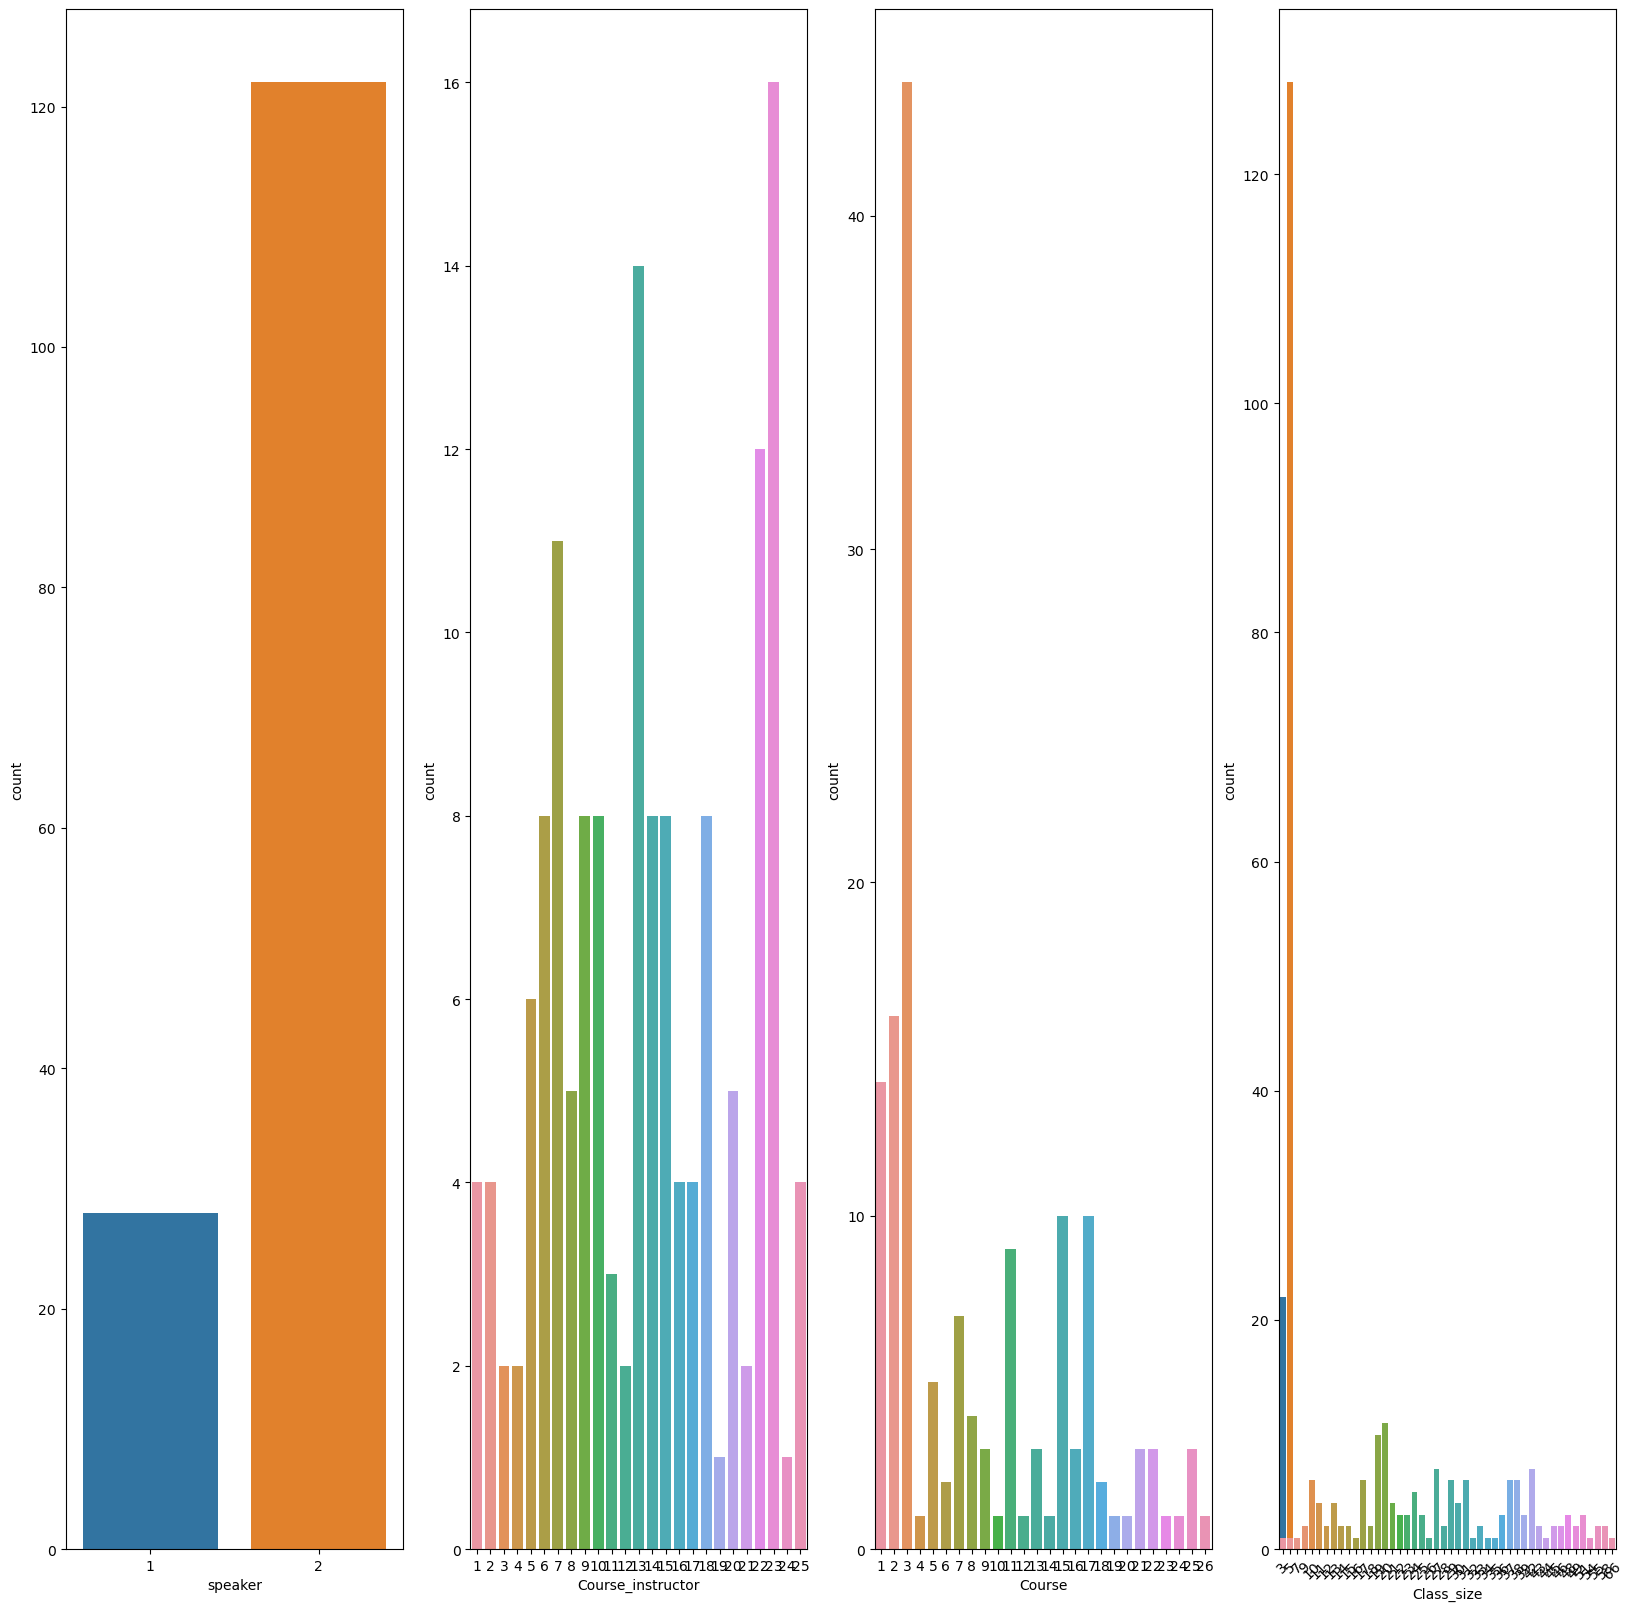

In [16]:
plt.figure(figsize = [20,20])
plt.subplot(141)
sns.countplot(data = df1, x='speaker')
plt.subplot(142)
sns.countplot(data = df1, x="Course_instructor")
plt.subplot(143)
sns.countplot(data = df1,x="Course")
plt.subplot(144)
plt.xticks(rotation = 45)
sns.countplot(data = df1, x="semester")
plt.xticks(rotation = 45)
sns.countplot(data = df1, x="Class_size")
plt.show()

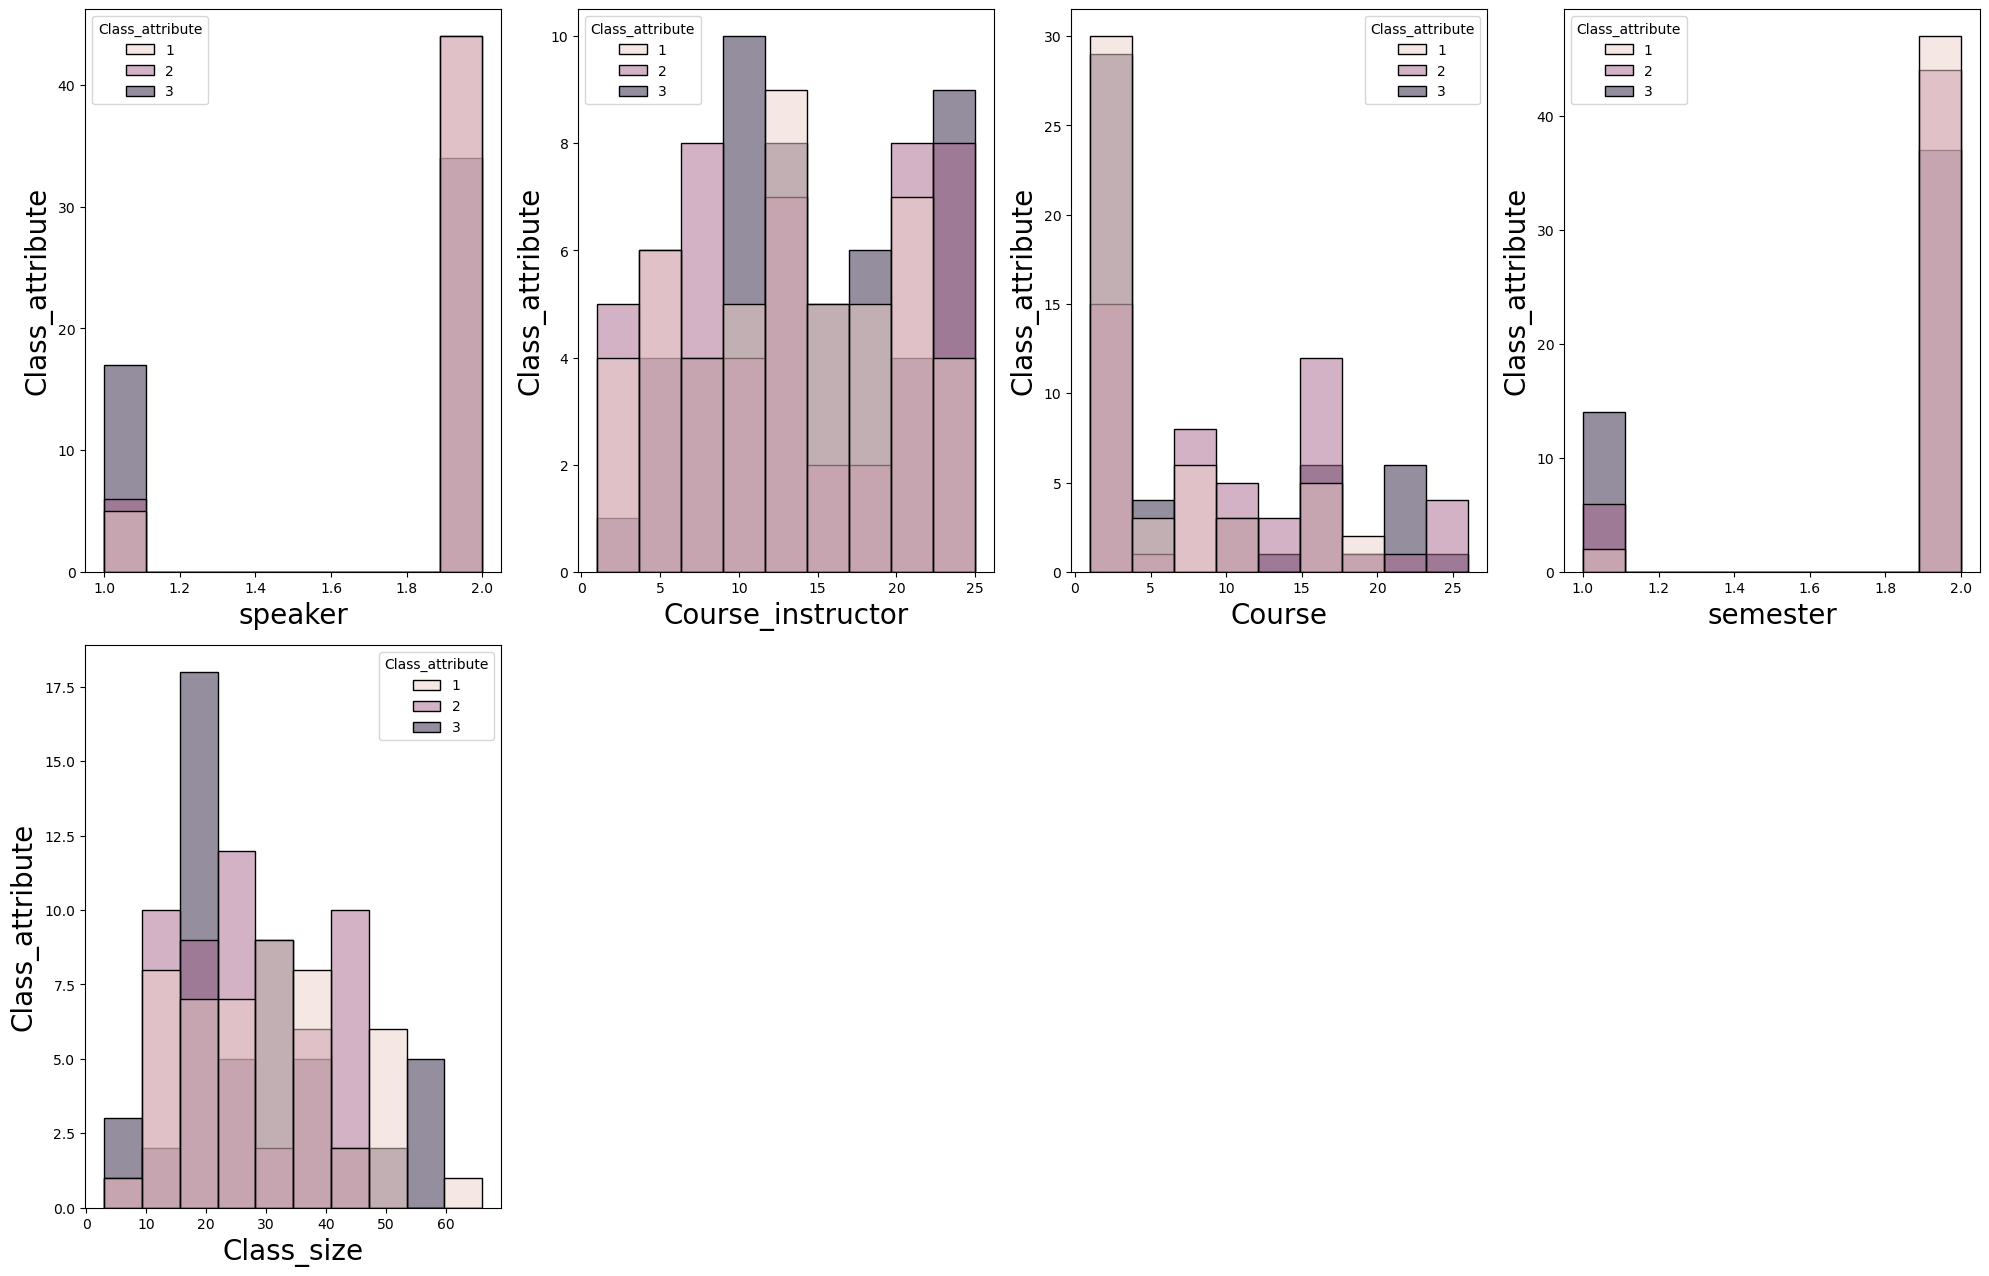

In [17]:
plt.figure(figsize=(20,25), facecolor='white')#To set canvas 
plotnumber = 1 #counter

for column in df1:#accessing the columns 
    if plotnumber<=16 :
        ax = plt.subplot(4,4,plotnumber)
        sns.histplot(x=df[column] ,hue=df.Class_attribute)
        plt.xlabel(column,fontsize=20)#assign name to x-axis and set font-20
        plt.ylabel('Class_attribute',fontsize=20)
    plotnumber+=1#counter increment
plt.tight_layout()

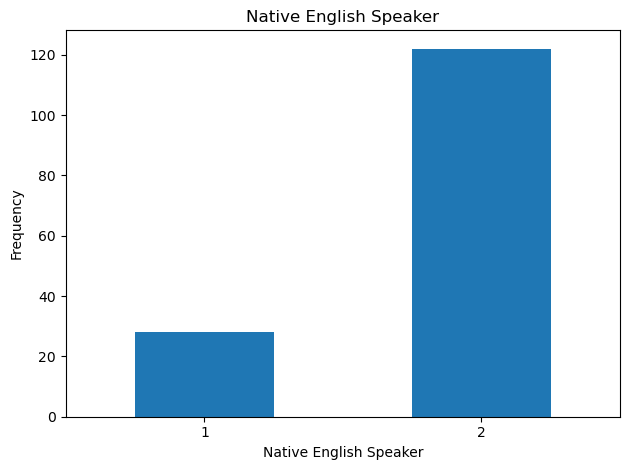

In [18]:
instructor_counts = df['speaker'].value_counts().sort_index()

instructor_counts.plot(kind='bar')
plt.title('Native English Speaker')
plt.xlabel('Native English Speaker')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

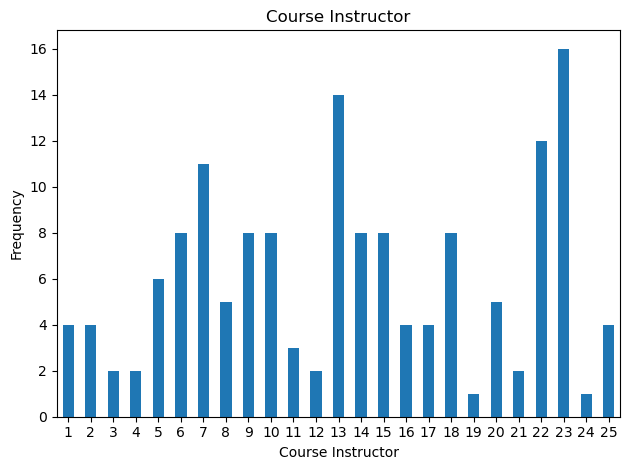

In [19]:
instructor_counts = df['Course_instructor'].value_counts().sort_index()

instructor_counts.plot(kind='bar')
plt.title('Course Instructor')
plt.xlabel('Course Instructor')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

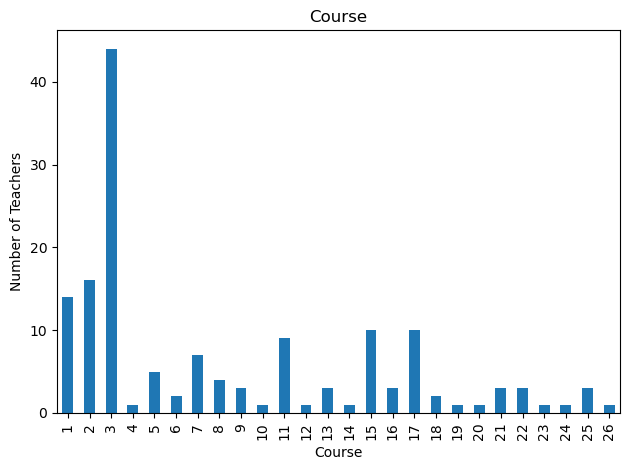

In [20]:
course_counts = df['Course'].value_counts().sort_index()
course_counts.plot(kind='bar')
plt.title('Course')
plt.xlabel('Course')
plt.ylabel('Number of Teachers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

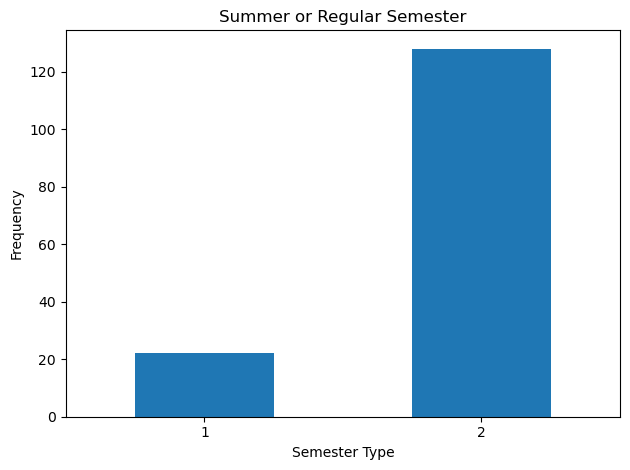

In [21]:
semester_counts = df['semester'].value_counts().sort_index()
semester_counts.plot(kind='bar')
plt.title('Summer or Regular Semester')
plt.xlabel('Semester Type')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

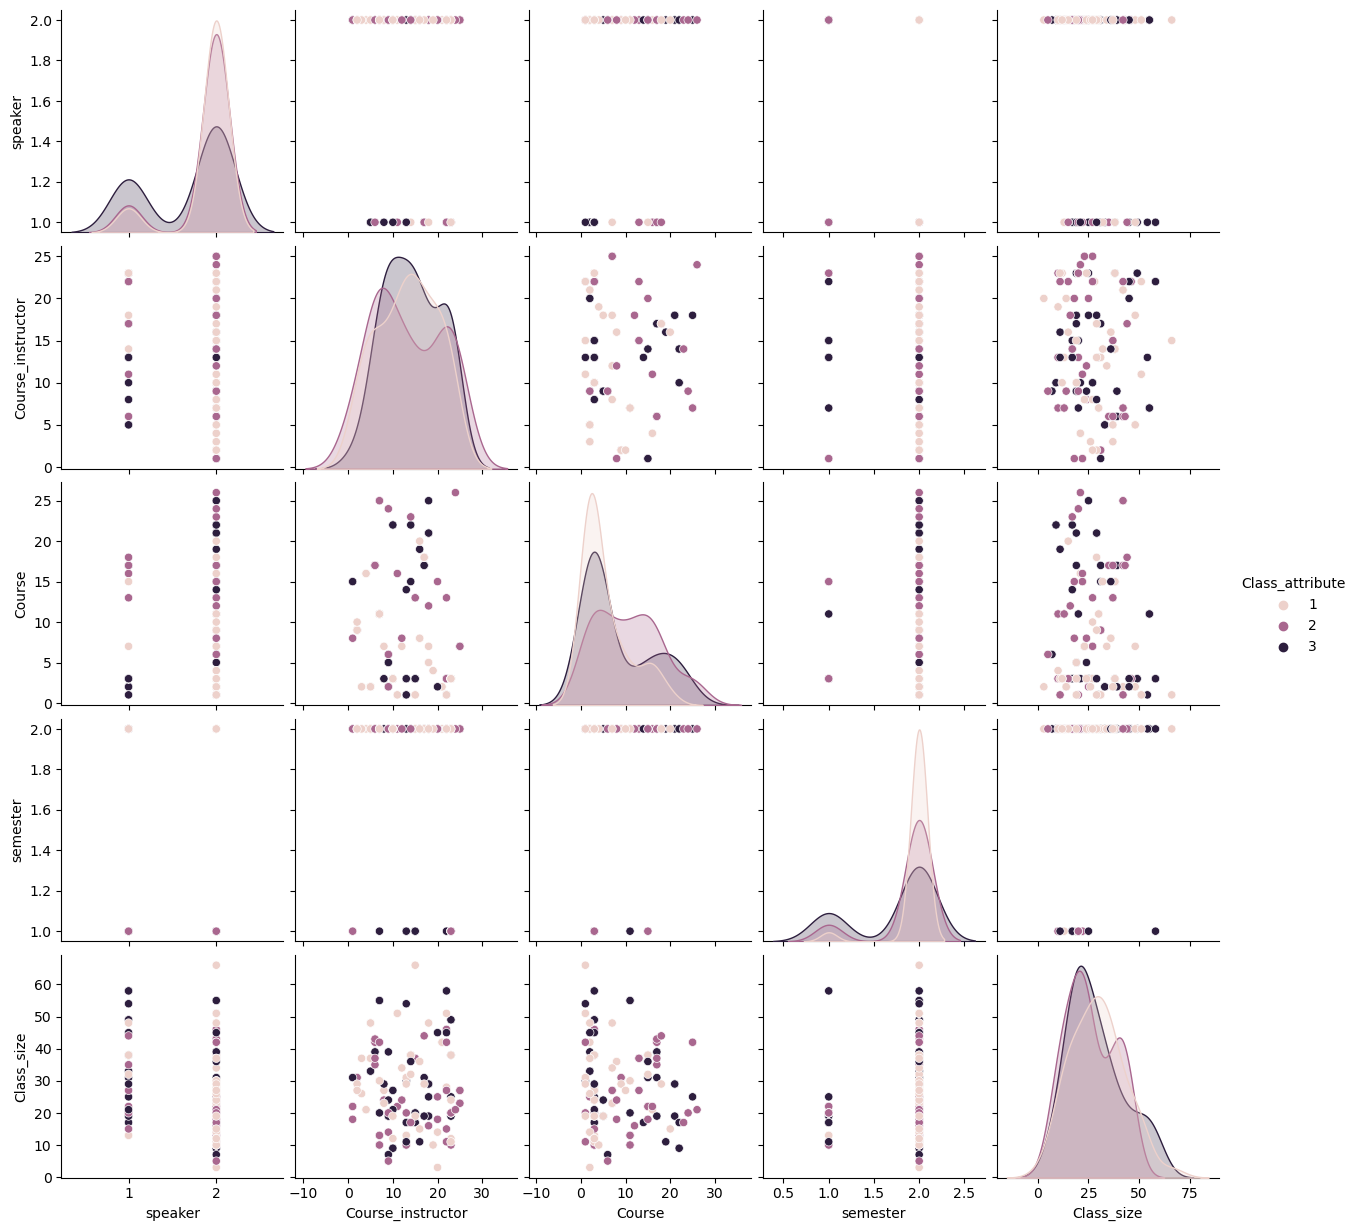

In [22]:
sns.pairplot(df,hue='Class_attribute')

<AxesSubplot:xlabel='speaker', ylabel='count'>

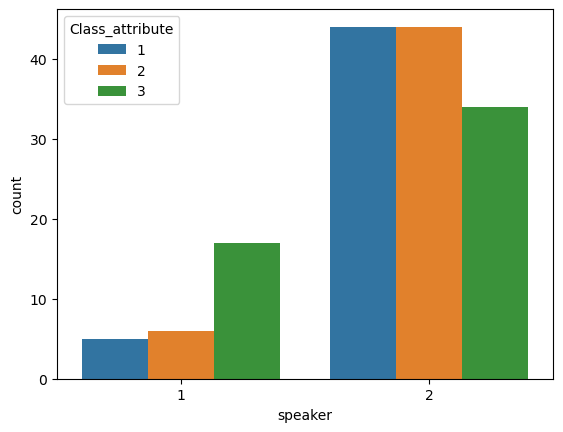

In [23]:
sns.countplot(x=df.speaker,hue=df.Class_attribute)

## Insights:
English Speaker: The distribution of English speakers (encoded as 2) and non-English speakers (encoded as 1) is shown in the histogram. The count or frequency of each category can be visualized.

Course Instructor: The histogram represents the distribution of different course instructors' identification numbers. It shows the frequency of each instructor in the dataset.

Course: The histogram displays the distribution of different course identification numbers. It provides insights into the frequency of each course in the dataset.

Semester: The histogram illustrates the distribution of semester numbers for the students. It shows the frequency of students in each semester.

Class Size: The histogram represents the distribution of class sizes for the students. It shows the frequency of students in different class size ranges.

Class Attribute: The histogram shows the distribution of class attributes encoded as integers (ranging from 1 to 3). It provides insights into the frequency of each class attribute in the dataset.

These histogram plots help visualize the distribution and relationships between different variables in the dataset, allowing for a better understanding of the data's characteristics.

In [24]:
import sweetviz as sv            # library for univariant analysis
my_report = sv.analyze(df)     # pass the original dataframe
my_report.show_html() 

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


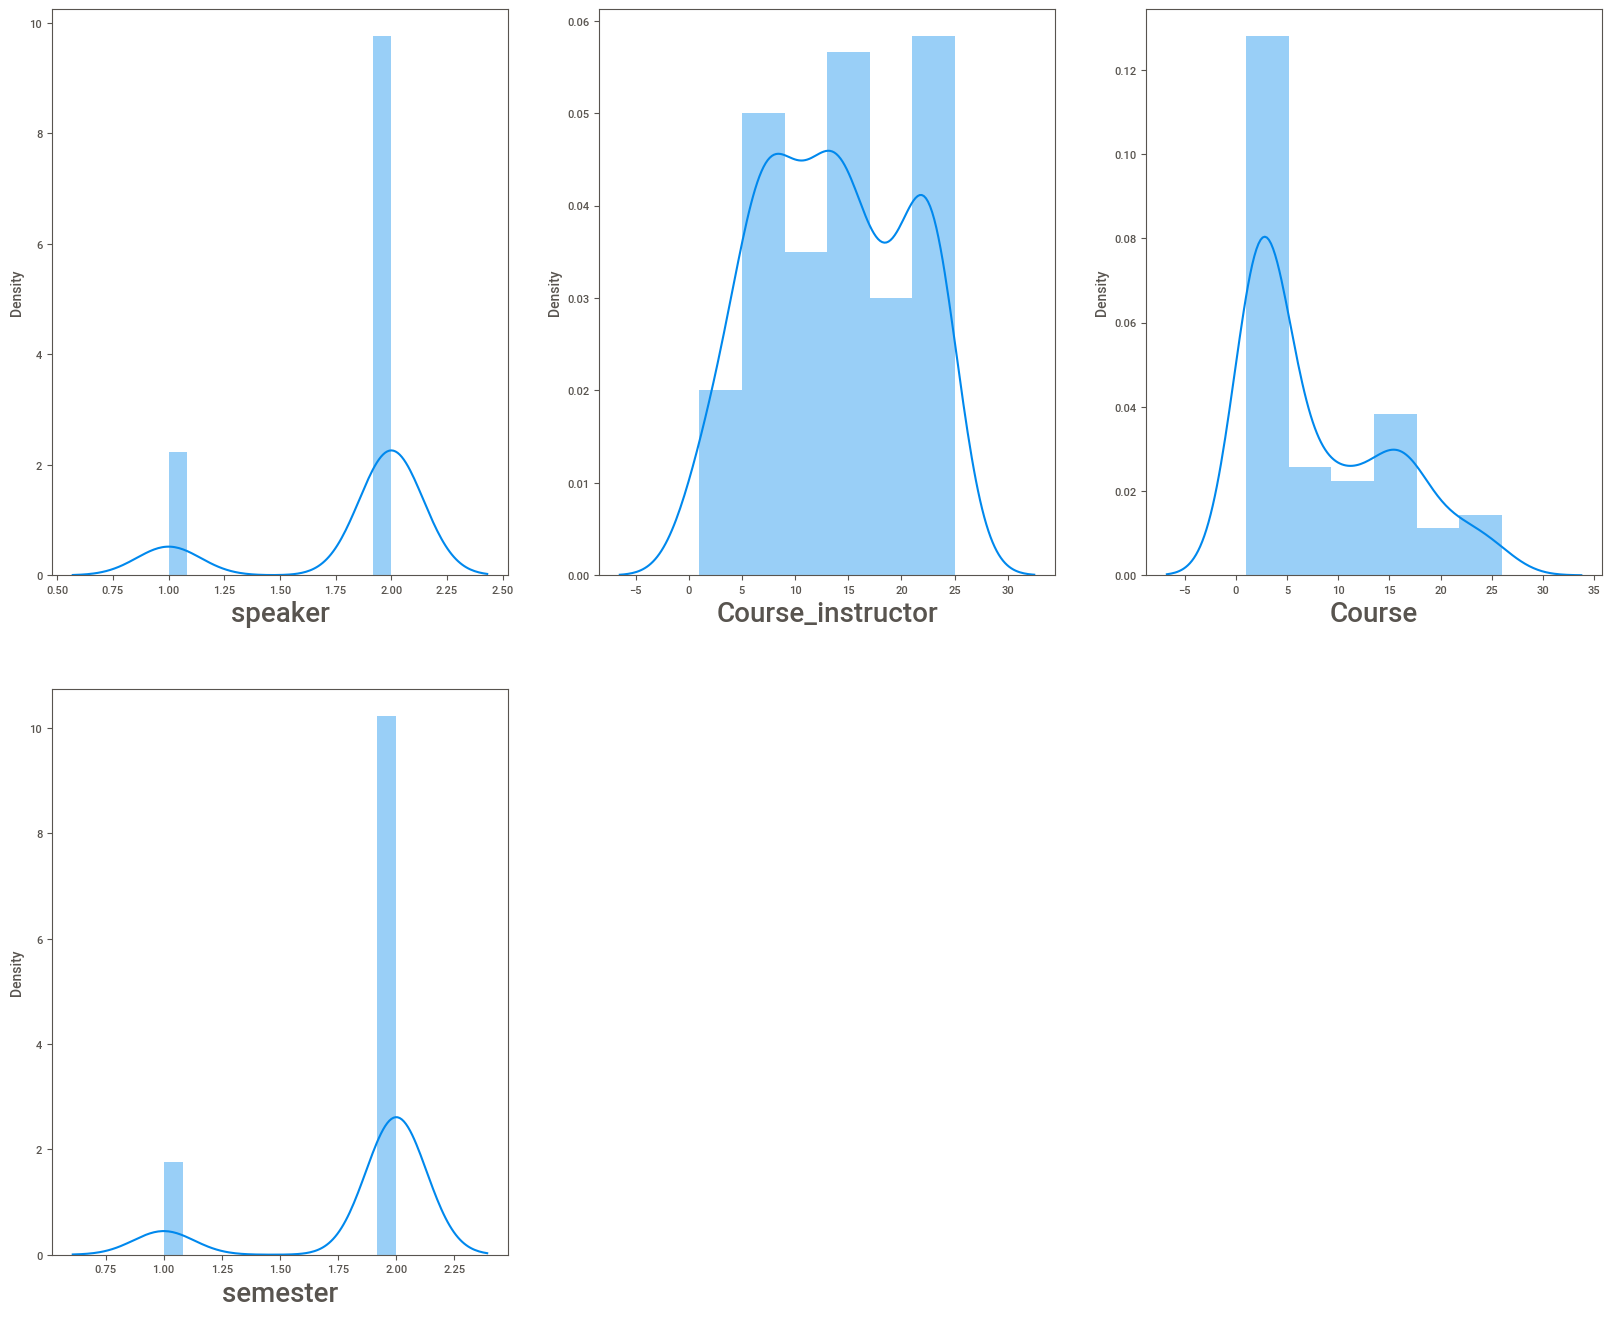

In [25]:
#how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')#defining  canvas size
plotnumber = 1 #maintian count for graph

for column in df:
    if plotnumber<=4 :# as there are 9 columns in the data
        ax = plt.subplot(3,3,plotnumber)# plotting 9 graphs (14-rows,4-columns) ,plotnumber is for count 
        sns.distplot(df1[column])#plotting dist plot to know distribution
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

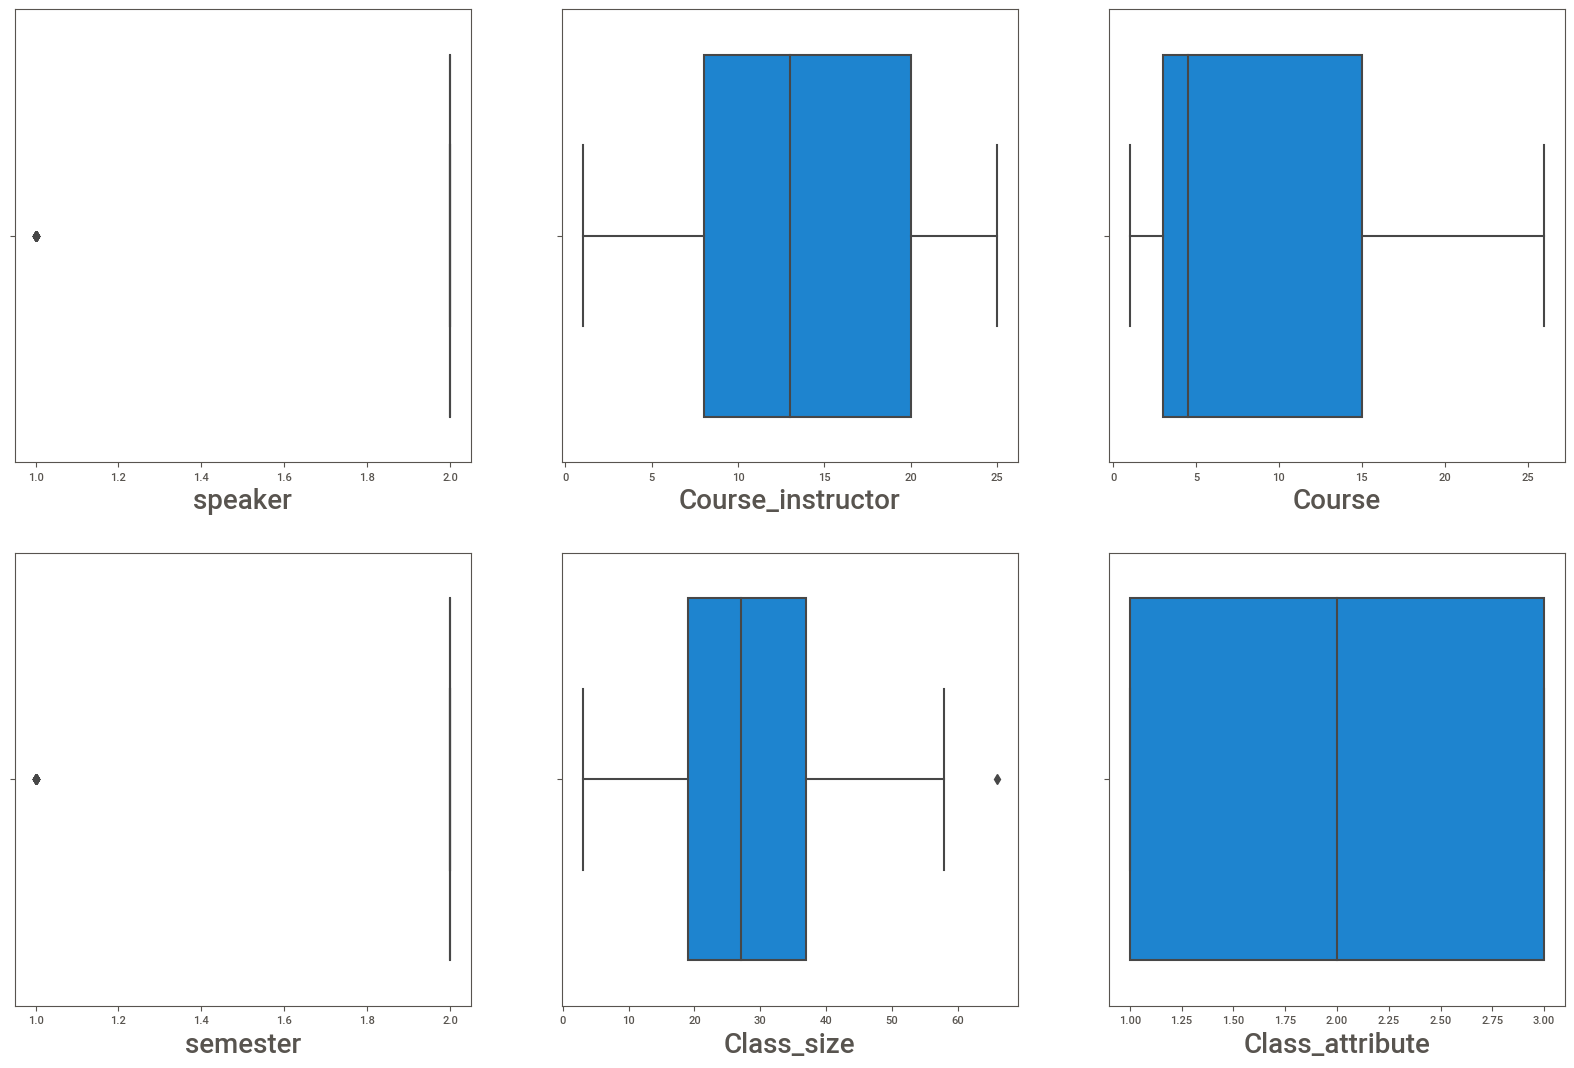

In [26]:
# Checking for outliers
# let's see how data is distributed for every column
plt.figure(figsize=(20,20), facecolor='white')
plotnumber = 1

for column in df:
    if plotnumber<=9 :
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(df[column]) 
        plt.xlabel(column,fontsize=20)
        
    plotnumber+=1
plt.show()

- Based on the box plots it appears that there are no extreme or unusual values in the dataset, hence there are no outliers present in the given dataset

## Feature Selection

### Heatmap

<AxesSubplot:>

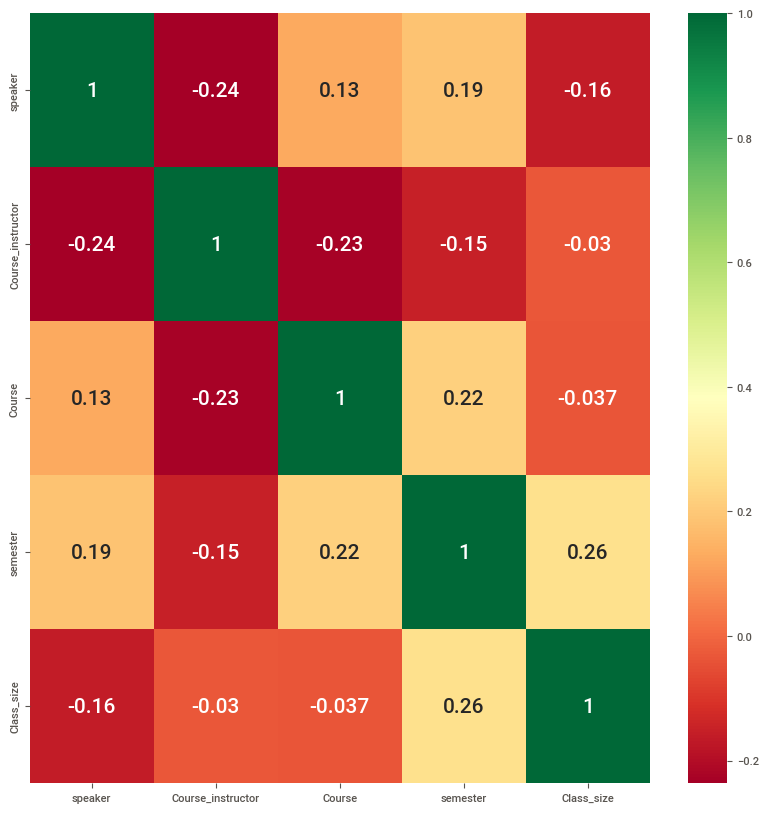

In [27]:
## Checking correlation

plt.figure(figsize=(10,10))#canvas size
sns.heatmap(df1.corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})#plotting heat map to check correlation

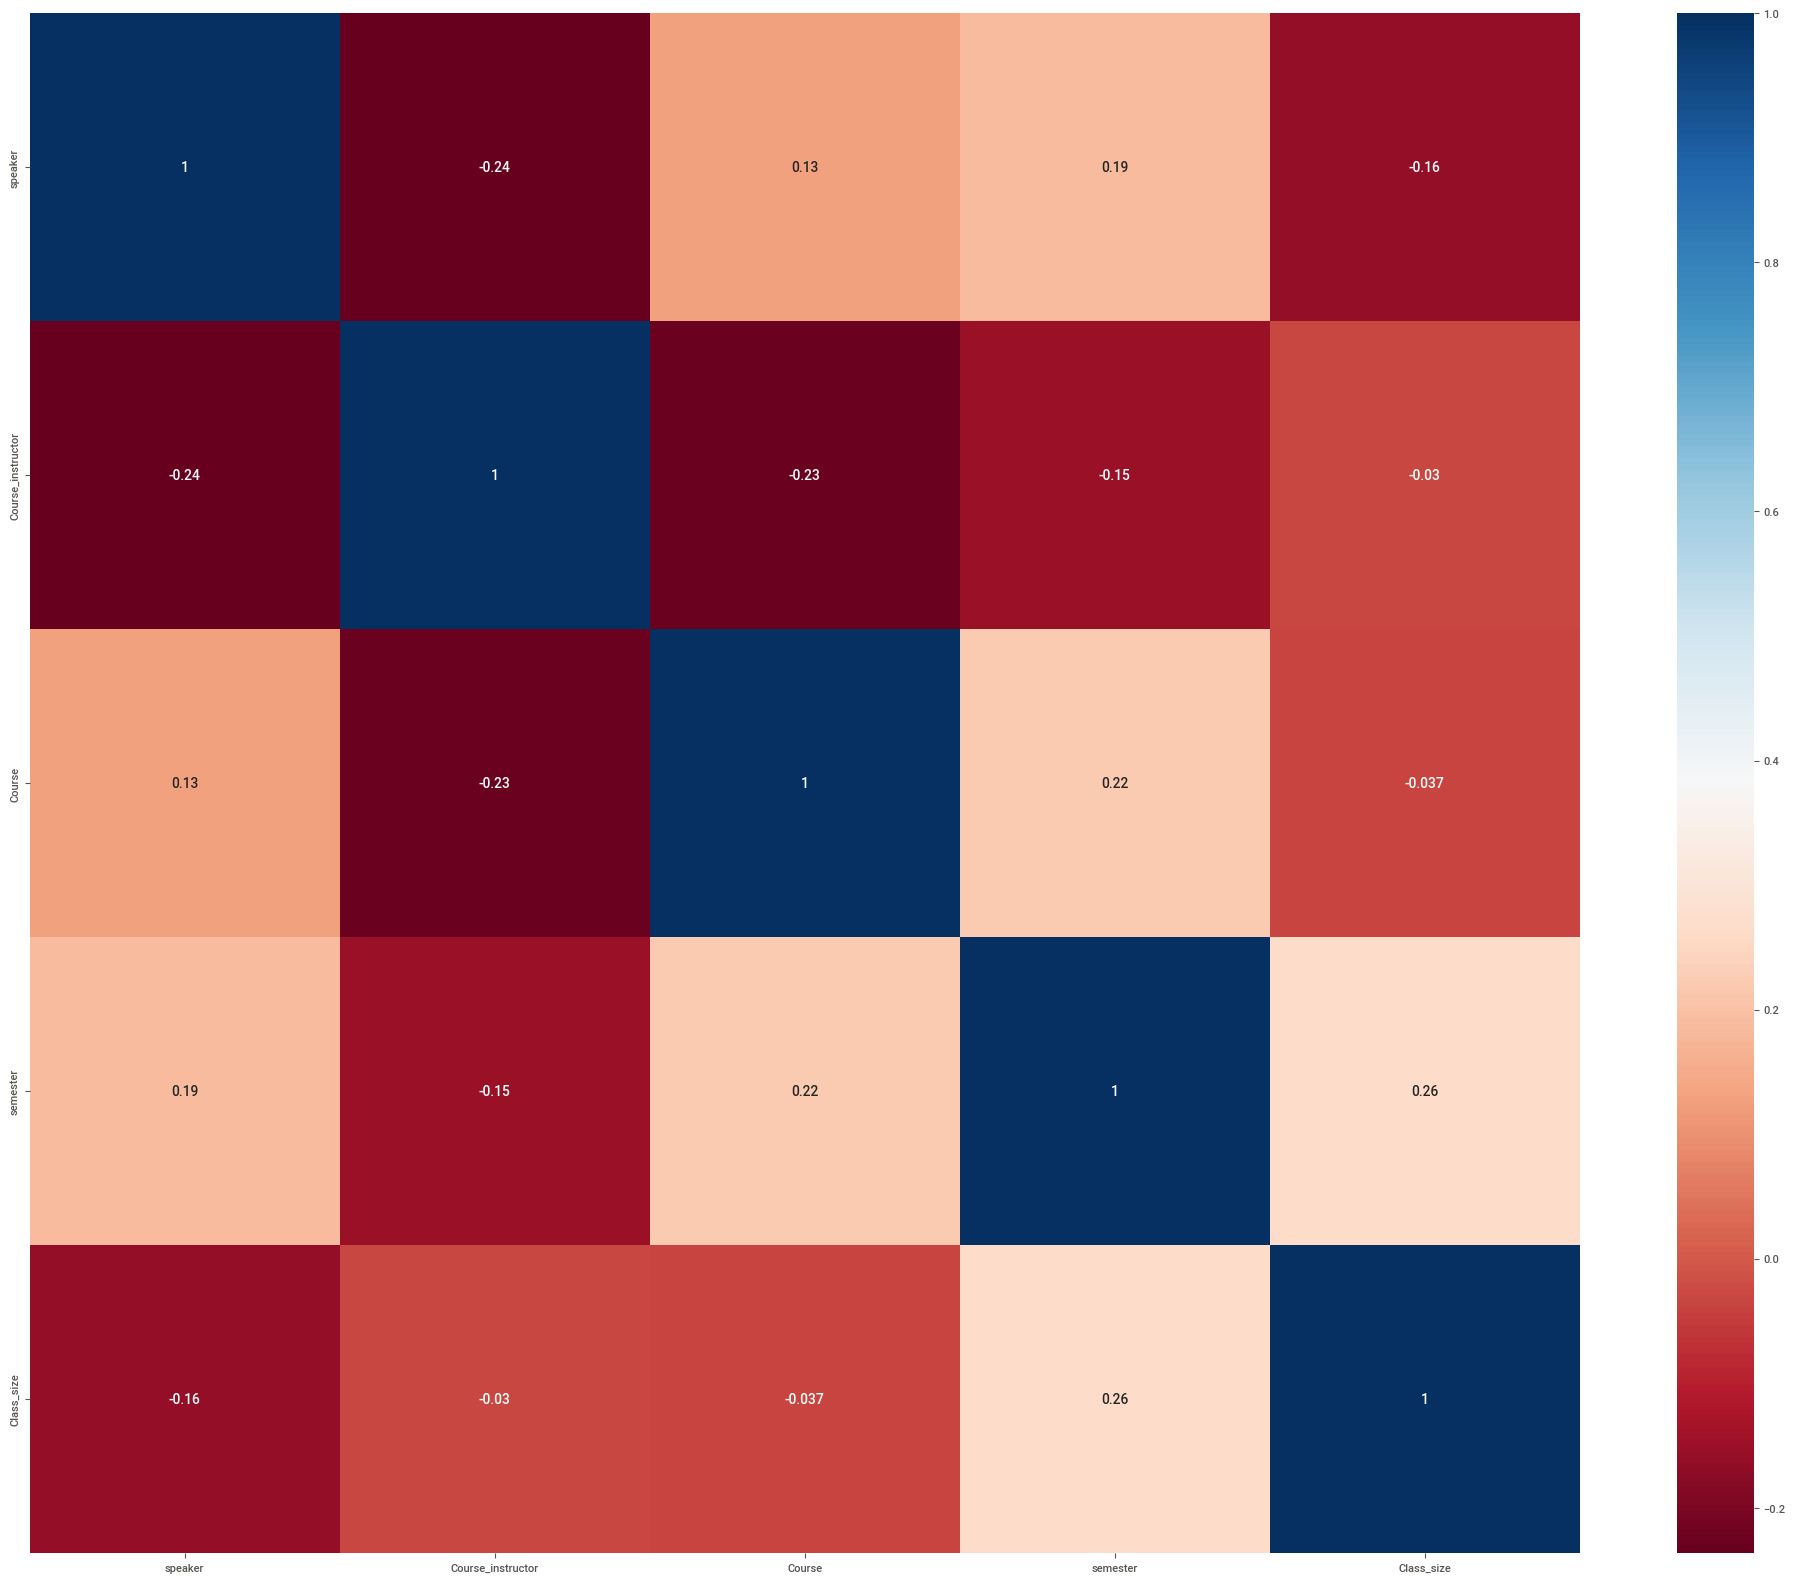

In [28]:
plt.figure(figsize = (25,20))
sns.heatmap(df1.corr(), annot = True, cmap= "RdBu")
plt.show()

- Upon analyzing the given dataset, it appears that there is a lack of significant correlation among the variables. The absence of strong correlations suggests that the variables do not exhibit a notable linear relationship with each other

## Splitting the data into X_train and y_train

In [29]:
X=df1     
y=df["Class_attribute"]

In [30]:
## creating training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split (X,y, test_size= 0.30, random_state=42)
#splitting data into train and test

## Logistic regression

In [31]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(multi_class='ovr')# logistic regression for multiclass classification ovr-> one vs rest
LR.fit(X_train,y_train)#  training model
y_hat=LR.predict(X_test)# predicting the results

In [32]:
print(classification_report(y_test,y_hat))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.61      0.78      0.68        18
           2       0.47      0.47      0.47        15
           3       0.57      0.33      0.42        12

    accuracy                           0.56        45
   macro avg       0.55      0.53      0.52        45
weighted avg       0.55      0.56      0.54        45



## SVC

In [33]:
from sklearn.svm import SVC
# Create an SVC classifier with the OvO strategy
svc = SVC(decision_function_shape='ovo')
svc.fit(X_train, y_train)
y_hat1 = svc.predict(X_test)

In [34]:
print(classification_report(y_test,y_hat1))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        18
           2       0.40      0.27      0.32        15
           3       0.23      0.67      0.34        12

    accuracy                           0.27        45
   macro avg       0.21      0.31      0.22        45
weighted avg       0.19      0.27      0.20        45



## Hyperparameter for SVM

In [35]:
from sklearn.model_selection import  GridSearchCV, RandomizedSearchCV
# Define the parameter grid for grid search
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Create an SVC classifier
svc = SVC()

# Perform grid search with cross-validation
random_search = RandomizedSearchCV(svc, param_grid, cv=5)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(),
                   param_distributions={'C': [0.1, 1, 10],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']})

In [36]:
# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'kernel': 'linear', 'gamma': 'scale', 'C': 1}


In [37]:
best_svc = SVC(C=1, gamma='auto', kernel='linear')

In [38]:
best_svc.fit(X_train, y_train)

# Make predictions on the test data
y_pred = best_svc.predict(X_test)

In [39]:
print(classification_report(y_test,y_pred))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.62      0.72      0.67        18
           2       0.47      0.53      0.50        15
           3       0.57      0.33      0.42        12

    accuracy                           0.56        45
   macro avg       0.55      0.53      0.53        45
weighted avg       0.56      0.56      0.55        45



## Decision tree

In [40]:
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree classifier
dt = DecisionTreeClassifier()

# Fit the classifier to the training data
dt.fit(X_train, y_train)

# Make predictions on the test data
y_hat2 = dt.predict(X_test)

In [41]:
print(classification_report(y_test,y_hat2))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.68      0.72      0.70        18
           2       0.57      0.53      0.55        15
           3       0.50      0.50      0.50        12

    accuracy                           0.60        45
   macro avg       0.59      0.59      0.58        45
weighted avg       0.60      0.60      0.60        45



[Text(0.538109756097561, 0.9666666666666667, 'X[2] <= 5.5\ngini = 0.664\nsamples = 105\nvalue = [31, 35, 39]'),
 Text(0.2225609756097561, 0.9, 'X[0] <= 1.5\ngini = 0.617\nsamples = 54\nvalue = [19, 9, 26]'),
 Text(0.0975609756097561, 0.8333333333333334, 'X[4] <= 20.5\ngini = 0.388\nsamples = 17\nvalue = [2, 2, 13]'),
 Text(0.04878048780487805, 0.7666666666666667, 'X[1] <= 17.5\ngini = 0.625\nsamples = 4\nvalue = [1, 2, 1]'),
 Text(0.024390243902439025, 0.7, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.07317073170731707, 0.7, 'X[3] <= 1.5\ngini = 0.444\nsamples = 3\nvalue = [0, 2, 1]'),
 Text(0.04878048780487805, 0.6333333333333333, 'X[4] <= 19.5\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.024390243902439025, 0.5666666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.07317073170731707, 0.5666666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.0975609756097561, 0.6333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0

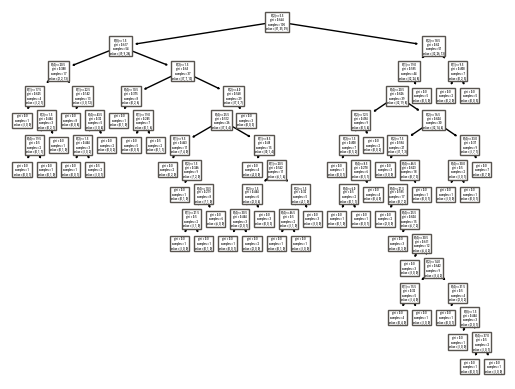

In [42]:
from sklearn import tree
tree.plot_tree(dt)

## Hyperparameter in decision tree

In [43]:
# Create a Decision Tree classifier
dt_classifier = DecisionTreeClassifier()

# Define the parameter grid for grid search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# Perform grid search with cross-validation
random_search = RandomizedSearchCV(dt_classifier, param_grid, cv=5)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 15],
                                        'min_samples_split': [2, 5, 10]})

In [44]:
# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'min_samples_split': 10, 'max_depth': 15, 'criterion': 'entropy'}


In [45]:
# Create a new Decision Tree classifier with the best hyperparameters
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2)

In [46]:
# Fit the classifier to the training data
best_dt.fit(X_train, y_train)

# Make predictions on the test data
y_pred2 = best_dt.predict(X_test)

In [47]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy)

Accuracy: 0.5777777777777777


In [48]:
print(classification_report(y_test, y_pred2))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.68      0.72      0.70        18
           2       0.50      0.40      0.44        15
           3       0.50      0.58      0.54        12

    accuracy                           0.58        45
   macro avg       0.56      0.57      0.56        45
weighted avg       0.57      0.58      0.57        45



## Random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
# Create a Random Forest classifier
rf_classifier = RandomForestClassifier()

# Fit the classifier to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat2 = rf_classifier.predict(X_test)

In [50]:
print(classification_report(y_test, y_hat2))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.68      0.72      0.70        18
           2       0.54      0.47      0.50        15
           3       0.54      0.58      0.56        12

    accuracy                           0.60        45
   macro avg       0.59      0.59      0.59        45
weighted avg       0.60      0.60      0.60        45



## Hyperparameter for random forest

In [51]:
# Create a Random Forest classifier
rf_classifier = RandomForestClassifier()

# Define the parameter grid for grid search
param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}
# Perform grid search with cross-validation
random_search = RandomizedSearchCV(rf_classifier, param_grid, cv=5)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [52]:
# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': None, 'criterion': 'entropy'}


In [53]:
best_rf_classifier = RandomForestClassifier(criterion='entropy', max_depth= None, min_samples_split= 5, n_estimators= 100)

In [54]:
# Fit the classifier to the training data
best_rf_classifier.fit(X_train, y_train)
# Make predictions on the test data
y_hat2_pred = best_rf_classifier.predict(X_test)

In [55]:
print(classification_report(y_test,y_hat2_pred))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.67      0.78      0.72        18
           2       0.70      0.47      0.56        15
           3       0.64      0.75      0.69        12

    accuracy                           0.67        45
   macro avg       0.67      0.66      0.66        45
weighted avg       0.67      0.67      0.66        45



## GradientBoostingClassifier

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

# Create a Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier()

# Fit the classifier to the training data
gb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat3 = gb_classifier.predict(X_test)

In [57]:
print(classification_report(y_test,y_hat3)) #recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.71      0.67      0.69        18
           2       0.64      0.60      0.62        15
           3       0.64      0.75      0.69        12

    accuracy                           0.67        45
   macro avg       0.66      0.67      0.67        45
weighted avg       0.67      0.67      0.67        45



## Hyper parameter for GradientBoostingClassifier

In [58]:
gb_classifier = GradientBoostingClassifier()

# Define the parameter grid for grid search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [3, 5, 7]
}

# Perform grid search with cross-validation
random_search = RandomizedSearchCV(gb_classifier, param_grid, cv=5)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'learning_rate': [0.1, 0.01, 0.001],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300]})

In [59]:
# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.001}


In [60]:
best_gb_classifier = GradientBoostingClassifier(learning_rate= 0.001, max_depth=5, n_estimators= 300)

In [61]:
# Fit the classifier to the training data
best_gb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat3_pr = best_gb_classifier.predict(X_test)

In [62]:
print(classification_report(y_test,y_hat3_pr))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.75      0.50      0.60        18
           2       0.44      0.47      0.45        15
           3       0.41      0.58      0.48        12

    accuracy                           0.51        45
   macro avg       0.53      0.52      0.51        45
weighted avg       0.56      0.51      0.52        45



## KNeighborsClassifier

In [63]:
from sklearn.neighbors import KNeighborsClassifier
# Create a KNN classifier
knn_classifier = KNeighborsClassifier()

# Fit the classifier to the training data
knn_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat4 = knn_classifier.predict(X_test)

In [64]:
print(classification_report(y_test,y_hat4))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.62      0.44      0.52        18
           2       0.33      0.27      0.30        15
           3       0.30      0.50      0.37        12

    accuracy                           0.40        45
   macro avg       0.42      0.40      0.40        45
weighted avg       0.44      0.40      0.41        45



## Hyperparameter for KNeighborsClassifier

In [65]:
# Create a KNN classifier
knn_classifier = KNeighborsClassifier()

# Define the parameter grid for grid search
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform grid search with cross-validation
random_search = RandomizedSearchCV(knn_classifier, param_grid, cv=5)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'metric': ['euclidean', 'manhattan'],
                                        'n_neighbors': [3, 5, 7],
                                        'weights': ['uniform', 'distance']})

In [66]:
# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'}


In [67]:
# Create a new KNN classifier with the best hyperparameters
best_knn_classifier = KNeighborsClassifier(metric= "euclidean" , n_neighbors= 7, weights="distance")

In [68]:
# Fit the classifier to the training data
best_knn_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat4_p = best_knn_classifier.predict(X_test)

In [69]:
print(classification_report(y_test,y_hat4_p))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.69      0.50      0.58        18
           2       0.50      0.40      0.44        15
           3       0.35      0.58      0.44        12

    accuracy                           0.49        45
   macro avg       0.51      0.49      0.49        45
weighted avg       0.54      0.49      0.50        45



## GaussianNB

In [70]:
from sklearn.naive_bayes import GaussianNB

# Create a Naive Bayes classifier
nb_classifier = GaussianNB()

# Fit the classifier to the training data
nb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat5 = nb_classifier.predict(X_test)

In [71]:
y_hat5_1 = nb_classifier.predict(X_train)

In [72]:
print(classification_report(y_train,y_hat5_1))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.48      0.74      0.58        31
           2       0.48      0.31      0.38        35
           3       0.65      0.56      0.60        39

    accuracy                           0.53       105
   macro avg       0.53      0.54      0.52       105
weighted avg       0.54      0.53      0.52       105



In [73]:
print(classification_report(y_test,y_hat5))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.58      0.83      0.68        18
           2       0.46      0.40      0.43        15
           3       0.67      0.33      0.44        12

    accuracy                           0.56        45
   macro avg       0.57      0.52      0.52        45
weighted avg       0.56      0.56      0.53        45



## Hyperparameter for GaussianNB

In [74]:
# Create a Naive Bayes classifier
nb_classifier = GaussianNB()

# Define the parameter grid for grid search
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

# Perform grid search with cross-validation
random_search = RandomizedSearchCV(nb_classifier, param_grid, cv=5)
random_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'var_smoothing': 1e-07}


In [75]:
# Create a new Naive Bayes classifier with the best hyperparameters
best_nb_classifier = GaussianNB(var_smoothing=1e-07)

# Fit the classifier to the training data
best_nb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_hat5_p = best_nb_classifier.predict(X_test)

In [76]:
print(classification_report(y_test,y_hat5_p))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.58      0.83      0.68        18
           2       0.46      0.40      0.43        15
           3       0.67      0.33      0.44        12

    accuracy                           0.56        45
   macro avg       0.57      0.52      0.52        45
weighted avg       0.56      0.56      0.53        45



## Best Model - RandomForestClassifier

In [77]:
from sklearn.ensemble import RandomForestClassifier
# RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_predictions = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("RandomForest Accuracy:", rf_accuracy)

RandomForest Accuracy: 0.6444444444444445


In [78]:
print(classification_report(y_test,rf_predictions))#recall,precision,f1 scores and accuracy

              precision    recall  f1-score   support

           1       0.68      0.72      0.70        18
           2       0.64      0.47      0.54        15
           3       0.60      0.75      0.67        12

    accuracy                           0.64        45
   macro avg       0.64      0.65      0.64        45
weighted avg       0.65      0.64      0.64        45



## Conclusion

### Insights:

The precision, recall, and F1-score provide an evaluation of the performance of a classification model. Here are the insights from the given classification report:

- Precision: Precision measures the accuracy of the positive predictions. For class 1, the precision is 0.68, indicating that 69% of the instances predicted as class 1 are correct. For class 2, the precision is 0.64, indicating 64% accuracy, and for class 3, the precision is 0.60, indicating 60% accuracy.

- Recall: Recall measures the ability of the model to identify the true positive instances. For class 1, the recall is 0.72, meaning that 72% of the actual class 1 instances were correctly identified. For class 2, the recall is 0.47, indicating that 47% of the actual class 2 instances were correctly identified. For class 3, the recall is 0.75, indicating that 75% of the actual class 3 instances were correctly identified.

- F1-score: The F1-score is the harmonic mean of precision and recall, providing a balanced measure of the model's performance. For class 1, the F1-score is 0.70, for class 2 it is 0.54, and for class 3 it is 0.67.

- Accuracy: The overall accuracy of the model is 0.64, meaning that 64% of the predictions made by the model are correct.

Overall, the model's performance is moderate, with accuracy, precision, recall, and F1-score ranging from 0.54 to 0.70.

### Observation: 
When we compare with multiple models we got to know that "Random Forest Classifier" is having good perfomance in the dataset